In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.spatial.distance import cdist
from scipy.stats import zscore
from itertools import combinations
import gseapy as gp
from gseapy.parser import download_library
from collections import defaultdict
from collections import Counter

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load in processed AnnData

In [2]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
# path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"
# path = "/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/processed_adata_wDEGs.h5ad"

adata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata

Memory usage: current 2.22 GB, difference +2.22 GB
Total time: 4.22 seconds


/home/jrcwycy/miniconda3/envs/scanpy/lib/python3.12/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variance

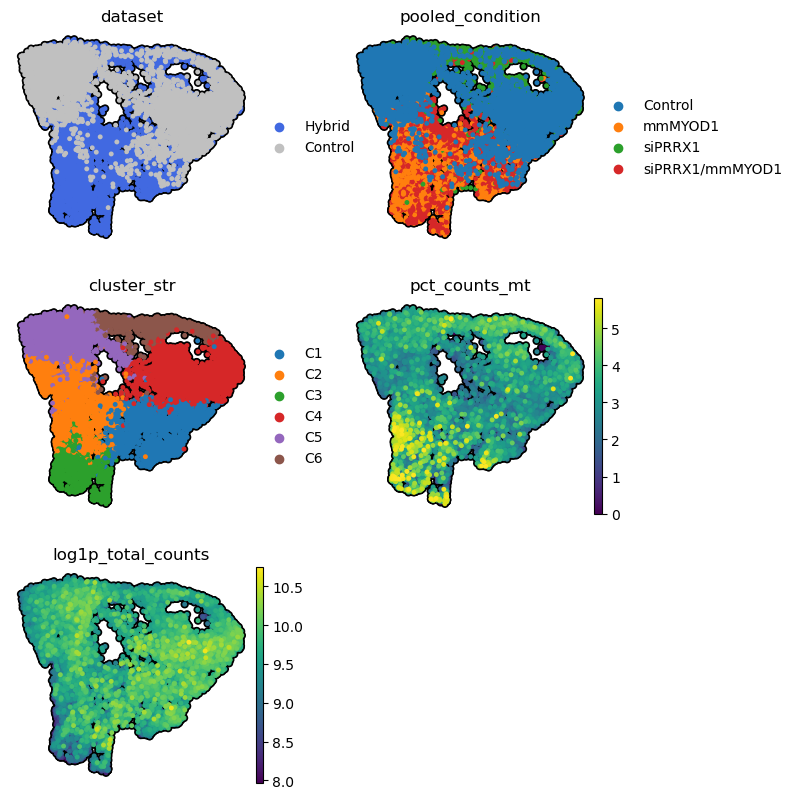

In [16]:
obs_to_plot = ['dataset', 'pooled_condition', 'cluster_str', 'pct_counts_mt', 'log1p_total_counts']

plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color=obs_to_plot,
    size=50,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Load in gene sets

In [2]:
### Transcription Factors
tfpath = "../resources/allTFs_hg38.txt"

with open(tfpath, 'r') as file:
    tf_list = [line.strip() for line in file]

print(len(tf_list))

1892


In [3]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [68]:
[col for col in geneset if "notch" in col.lower()]

[]

In [ ]:
# Notch1 --> turns on HES/HEY; 
# NUM 

In [27]:
### Negative apoptosis
neg_apop_terms = [
    'Negative Regulation of Apoptotic Process (GO:0043066)',
    'Negative Regulation of Apoptotic Signaling Pathway (GO:2001234)',
    '- Reg of Endoplasmic Reticulum Stress-Induced Intrinsic Apoptotic Sgnlng Pway (GO:1902236)',
    'Negative Regulation of Extrinsic Apoptotic Signaling Pathway (GO:2001237)',
    'Negative Regulation of Intrinsic Apoptotic Signaling Pathway (GO:2001243)',
    'Negative Regulation of Intrinsic Apoptotic Signaling Pathway by P53 Class Mediator (GO:1902254)',
    'Negative Regulation of Intrinsic Apoptotic Signaling Pathway in Response to DNA Damage (GO:1902230)',
    'Negative Regulation of Oxidative Stress-Induced Intrinsic Apoptotic Signaling Pathway (GO:1902176)',
    'Negative Regulation of Execution Phase of Apoptosis (GO:1900118)',
]
print(f"N neg apoptosis terms: {len(neg_apop_terms)}")
df = geneset[neg_apop_terms]
neg_apop_genes = list(set(df.stack().tolist()))
print(f"N neg apoptosis genes: {len(neg_apop_genes)}\n")
    
### Positive apoptosis    
pos_apop_terms = [
    'Positive Regulation of Apoptotic Cell Clearance (GO:2000427)',
    'Positive Regulation of Apoptotic Process (GO:0043065)',
    'Positive Regulation of Apoptotic Signaling Pathway (GO:2001235)',
    '+ Reg of Endoplasmic Reticulum Stress-Induced Intrinsic Apoptotic Sgnlng Pway (GO:1902237)',
    'Positive Regulation of Extrinsic Apoptotic Signaling Pathway (GO:2001238)',
    'Positive Regulation of Fibroblast Apoptotic Process (GO:2000271)',
    'Positive Regulation of Intrinsic Apoptotic Signaling Pathway (GO:2001244)',
    'Positive Regulation of Intrinsic Apoptotic Signaling Pathway by P53 Class Mediator (GO:1902255)',
    'Positive Regulation of Execution Phase of Apoptosis (GO:1900119)',
]
print(f"N pos apoptosis terms: {len(pos_apop_terms)}")
df = geneset[pos_apop_terms]
pos_apop_genes = list(set(df.stack().tolist()))
print(f"N pos apoptosis genes: {len(pos_apop_genes)}\n")


overlap = set(neg_apop_genes) & set(pos_apop_genes)
print(f"N overlapping apoptosis genes: {len(overlap)}")

N neg apoptosis terms: 9
N neg apoptosis genes: 560

N pos apoptosis terms: 9
N pos apoptosis genes: 365

N overlapping apoptosis genes: 74


In [31]:
# Chromatin remodeling
chromatin_terms = [col for col in geneset if "chromatin" in col.lower()]
print(f"N chromatin terms: {len(chromatin_terms)}")
df = geneset[chromatin_terms]
chromatin_genes = list(set(df.stack().tolist()))
print(f"N chromatin genes: {len(chromatin_genes)}\n")

# DNA damage genes
damage_terms = [col for col in geneset if "dna damage" in col.lower()]
print(f"N dna damage terms: {len(damage_terms)}")
df = geneset[damage_terms]
damage_genes = list(set(df.stack().tolist()))
print(f"N dna damage genes: {len(damage_genes)}\n")


# TF activity 
tf_terms = [
    'Positive Regulation of DNA-binding Transcription Factor Activity (GO:0051091)', # "of" is capitalized in GO 2023
    'Negative Regulation of DNA-binding Transcription Factor Activity (GO:0043433)',
]
print(f"N TF activity terms: {len(tf_terms)}")
df = geneset[tf_terms]
tf_genes = list(set(df.stack().tolist()))
print(f"N TF activity genes: {len(tf_genes)}\n")


# Senescence genes
senescence_terms = [col for col in geneset if "senescence" in col.lower()]
print(f"N senescence terms: {len(senescence_terms)}")
df = geneset[senescence_terms]
senescence_genes = list(set(df.stack().tolist()))
print(f"N senescence genes: {len(senescence_genes)}\n")


# Circadian rythym genes
circadian_terms = [col for col in geneset if "circadian" in col.lower()]
print(f"N circadian terms: {len(circadian_terms)}")
df = geneset[circadian_terms]
circadian_genes = list(set(df.stack().tolist()))
print(f"N circadian genes: {len(circadian_genes)}\n")


# Alternative splicing genes
splice_terms = [col for col in geneset if "splice" in col.lower()]
print(f"N AS terms: {len(splice_terms)}")
df = geneset[splice_terms]
splice_genes = list(set(df.stack().tolist()))
print(f"N AS genes: {len(splice_genes)}\n")


# Cell cycle genes
cc_terms = [col for col in geneset if "cell cycle" in col.lower()]
print(f"N cell cycle terms: {len(cc_terms)}")
df = geneset[cc_terms]
cc_genes = list(set(df.stack().tolist()))
print(f"N cell cycle genes: {len(cc_genes)}\n")

N chromatin terms: 25
N chromatin genes: 511

N dna damage terms: 22
N dna damage genes: 540

N TF activity terms: 2
N TF activity genes: 284

N senescence terms: 3
N senescence genes: 35

N circadian terms: 5
N circadian genes: 42

N AS terms: 14
N AS genes: 281

N cell cycle terms: 45
N cell cycle genes: 832



In [36]:
fpath = "../resources/CellAge_senescence_signature.csv"

df = pd.read_csv(fpath)

senes_up = df[df['Expression'] == 'Over-expressed']
senes_up_genes = senes_up['Symbol'].unique()
print(f"N unique genes overexpressed in senescence: {len(senes_up_genes)}")

senes_down = df[df['Expression'] == 'Under-expressed']
senes_down_genes = senes_down['Symbol'].unique()
print(f"N unique genes underexpressed in senescence: {len(senes_down_genes)}")

N unique genes overexpressed in senescence: 525
N unique genes underexpressed in senescence: 734


In [56]:
# Quiescence-related TFs from Mitra et al. (2025)
quiescence_genes = [
    "ATF3", "ATF4", "CTNNB1", "BACH2", "JUN", "CEBPB", "CEBPA", "CTCF",
    "E2F4", "E2F5", "E2F1", "E2F2", "E2F3", "ERG", "ETS1", "MECOM", "FOXC1", "FOXM1", "FOXO3",
    "FOXP1", "GATA6", "GFI1", "HES1", "HLF", "ID1", "ID4", "IKZF1", "KLF2", "KLF4", "KLF7",
    "KLF9", "LEF1", "MECP2", "MED1", "ELF4", "MXI1", "MYC", "NFKB1", "NKX2-3", "RBPJ", "NFE2L2", 
    "RARA", "NR1H3", "NR4A2", "PAX3", "PAX7", "PBX1", "PPARD", "SPI1", "REST", "RUNX1", "SALL2", "SATB1", 
    "TAL1", "STAT1", "STAT3", "STAT4", "TCF15", "TLE4", "TP53", "YAP1", "YY1", "ZEB1", "ZFP521", "ZNF521",
]

print(f"N total TFs: {len(quiescence_genes)}")

qui_tfs = [gene for gene in quiescence_genes if gene in adata.var_names]

print(f"N quiescence TFs in adata: {len(qui_tfs)}\n")
# print(", ".join(genes))

N total TFs: 65
N quiescence TFs in adata: 59



In [32]:
### Core reprogramming regulators, cell cycle, and circadian genes from Liu 2018 paper (supplemental table S3, S4)
fpath = "../resources/liu_core_genes.csv"
df = pd.read_csv(fpath)

# core muscle and fibroblast reprogramming regulators
core_regulators = list(set(df[['Fibroblast', 'Muscle']].stack().tolist()))
print(f"N core regulators of MYOD1-mediated reprogramming: {len(core_regulators)}")

# core circadian genes
core_circadian = df['Circadian'].unique()
print(f"N core circadian genes: {len(core_circadian)}")

# combine with GO circadian genes
circadian = list(set(core_circadian) | set(circadian_genes))
print(f"N total circadian genes: {len(circadian)}\n")


### Cell-type specific marker genes from PanglaoDB 2021 and Tabula Sapiens
fpath = "../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)

cells = ['skeletal_muscle', 'myocyte', 'myoblast']
myogenic = mdf[mdf['category'].isin(cells)]['gene_name'].dropna().unique()
print(f"N skeletal muscle/myocyte/myoblast genes: {len(myogenic)}")

fibroblast = mdf[mdf['category'] == 'fibroblast']['gene_name'].dropna().unique()
print(f"N fibroblast genes: {len(fibroblast)}")

myofibroblast = mdf[mdf['category'] == 'myofibroblast']['gene_name'].dropna().unique()
print(f"N myofibroblast genes: {len(myofibroblast)}")

N core regulators of MYOD1-mediated reprogramming: 144
N core circadian genes: 28
N total circadian genes: 61

N skeletal muscle/myocyte/myoblast genes: 455
N fibroblast genes: 461
N myofibroblast genes: 240


In [57]:
### Combine into 1 data object
categories = {
    'TFs': tf_list,
    'Fibroblasts': fibroblast,
    'Myofibroblasts': myofibroblast,
    'Myogenic': myogenic,
    'cell_cycle': cc_genes,
    'AS': splice_genes,
    'Circadian': circadian,
    'Core_reprogramming': core_regulators,
    'Senescence_GO': senescence_genes,
    'Senescence_UP': senes_up_genes,
    'Senescence_DOWN': senes_down_genes,
    'DNA_damage': damage_genes,
    'Chromatin_remodeling': chromatin_genes, 
    'TF_activity': tf_genes,
    'Pos_apoptosis': pos_apop_genes, 
    'Neg_apoptosis': neg_apop_genes,
    'Quiescence_TFs': qui_tfs,
}

for key, gene_list in categories.items():
    print(f"N genes for {key}: {len(gene_list)}")
    
# make into a dataframe
cleaned_categories = {k: list(np.ravel(v)) for k, v in categories.items()}
max_len = max(len(v) for v in cleaned_categories.values())
padded = {k: v + [None] * (max_len - len(v)) for k, v in cleaned_categories.items()}

cdf = pd.DataFrame(padded)
cdf.head()

N genes for TFs: 1892
N genes for Fibroblasts: 461
N genes for Myofibroblasts: 240
N genes for Myogenic: 455
N genes for cell_cycle: 832
N genes for AS: 281
N genes for Circadian: 61
N genes for Core_reprogramming: 144
N genes for Senescence_GO: 35
N genes for Senescence_UP: 525
N genes for Senescence_DOWN: 734
N genes for DNA_damage: 540
N genes for Chromatin_remodeling: 511
N genes for TF_activity: 284
N genes for Pos_apoptosis: 365
N genes for Neg_apoptosis: 560
N genes for Quiescence_TFs: 59


,TFs,Fibroblasts,Myofibroblasts,Myogenic,cell_cycle,AS,Circadian,Core_reprogramming,Senescence_GO,Senescence_UP,Senescence_DOWN,DNA_damage,Chromatin_remodeling,TF_activity,Pos_apoptosis,Neg_apoptosis,Quiescence_TFs
0,ZNF354C,RARRES2,LUM,SLC5A1,HCFC1,CWC27,TEF,HDAC9,NUAK1,ABCA3,AASS,EXO1,H2AJ,IL1B,RBM5,NUGGC,ATF3
1,KLF12,CELA1,PRRX1,LOX,KANK2,DDX20,SFPQ,POLR2C,PNPT1,ABHD4,ABHD3,NRBP2,HCFC1,FER,PRNP,UBE2Z,ATF4
2,ZNF143,LUM,COL1A1,LMOD1,NUGGC,RBM3,THRAP3,PTN,TERT,ACYP2,ACTL6A,INO80E,INO80E,NEUROG2,UBE2Z,CX3CL1,CTNNB1
3,ZIC2,PRRX1,COL5A2,EDNRA,RFPL1,RBM5,NKX2-1,JUN,SIRT1,ADAM19,ACTR5,CDK3,HDAC8,RIPK4,CAV1,UNC5B,BACH2
4,ZNF274,SCARA5,COL5A1,AQP1,MARK4,RBM23,LOC102724428,MED31,TP53,ADAM23,ADAMTS6,WNT1,BAZ2A,TLR4,LATS1,NRBP2,JUN


#

In [38]:
adata

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

# Load in DEGs

In [41]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]
    tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
    
    if pct_nz_thresh != 0.0:
        print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp


deg_path_condition = "/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/DEGs_by_condition_vs_control.csv"
deg_path_cluster = "/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/DEGs_by_cluster.csv"

deg_condition = pd.read_csv(deg_path_condition)
print(deg_condition.shape)
deg_cluster = pd.read_csv(deg_path_cluster)
print(deg_cluster.shape)

sig_condition = get_significant_DEGs(deg_condition, pct_nz_thresh=0.4) 
sig_cluster = get_significant_DEGs(deg_cluster, pct_nz_thresh=0.4)

(75378, 8)
(150756, 9)
Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed genes expressed in less than 40.0% of cells.
N unique significant DEGs: 2689

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed genes expressed in less than 40.0% of cells.
N unique significant DEGs: 3119



In [44]:
overlap = set(sig_condition['names'].unique()) & set(sig_cluster['names'].unique())
print(len(overlap))

2040


In [66]:
print(cdf.shape)
cdf.head()

(1892, 17)


,TFs,Fibroblasts,Myofibroblasts,Myogenic,cell_cycle,AS,Circadian,Core_reprogramming,Senescence_GO,Senescence_UP,Senescence_DOWN,DNA_damage,Chromatin_remodeling,TF_activity,Pos_apoptosis,Neg_apoptosis,Quiescence_TFs
0,ZNF354C,RARRES2,LUM,SLC5A1,HCFC1,CWC27,TEF,HDAC9,NUAK1,ABCA3,AASS,EXO1,H2AJ,IL1B,RBM5,NUGGC,ATF3
1,KLF12,CELA1,PRRX1,LOX,KANK2,DDX20,SFPQ,POLR2C,PNPT1,ABHD4,ABHD3,NRBP2,HCFC1,FER,PRNP,UBE2Z,ATF4
2,ZNF143,LUM,COL1A1,LMOD1,NUGGC,RBM3,THRAP3,PTN,TERT,ACYP2,ACTL6A,INO80E,INO80E,NEUROG2,UBE2Z,CX3CL1,CTNNB1
3,ZIC2,PRRX1,COL5A2,EDNRA,RFPL1,RBM5,NKX2-1,JUN,SIRT1,ADAM19,ACTR5,CDK3,HDAC8,RIPK4,CAV1,UNC5B,BACH2
4,ZNF274,SCARA5,COL5A1,AQP1,MARK4,RBM23,LOC102724428,MED31,TP53,ADAM23,ADAMTS6,WNT1,BAZ2A,TLR4,LATS1,NRBP2,JUN


In [67]:
# cdf.to_csv("../resources/genes_for_scoring.csv")

Skipping TFs, scores already exist.
Skipping Fibroblasts, scores already exist.
Skipping Myofibroblasts, scores already exist.
Skipping Myogenic, scores already exist.
Skipping cell_cycle, scores already exist.
Skipping AS, scores already exist.
Skipping Circadian, scores already exist.
Skipping Core_reprogramming, scores already exist.
Skipping Senescence_GO, scores already exist.
Skipping Senescence_UP, scores already exist.
Skipping Senescence_DOWN, scores already exist.
Skipping DNA_damage, scores already exist.
Skipping Chromatin_remodeling, scores already exist.
Skipping TF_activity, scores already exist.
Skipping Pos_apoptosis, scores already exist.
Skipping Neg_apoptosis, scores already exist.
Skipping Quiescence_TFs, scores already exist.
Finished.
34


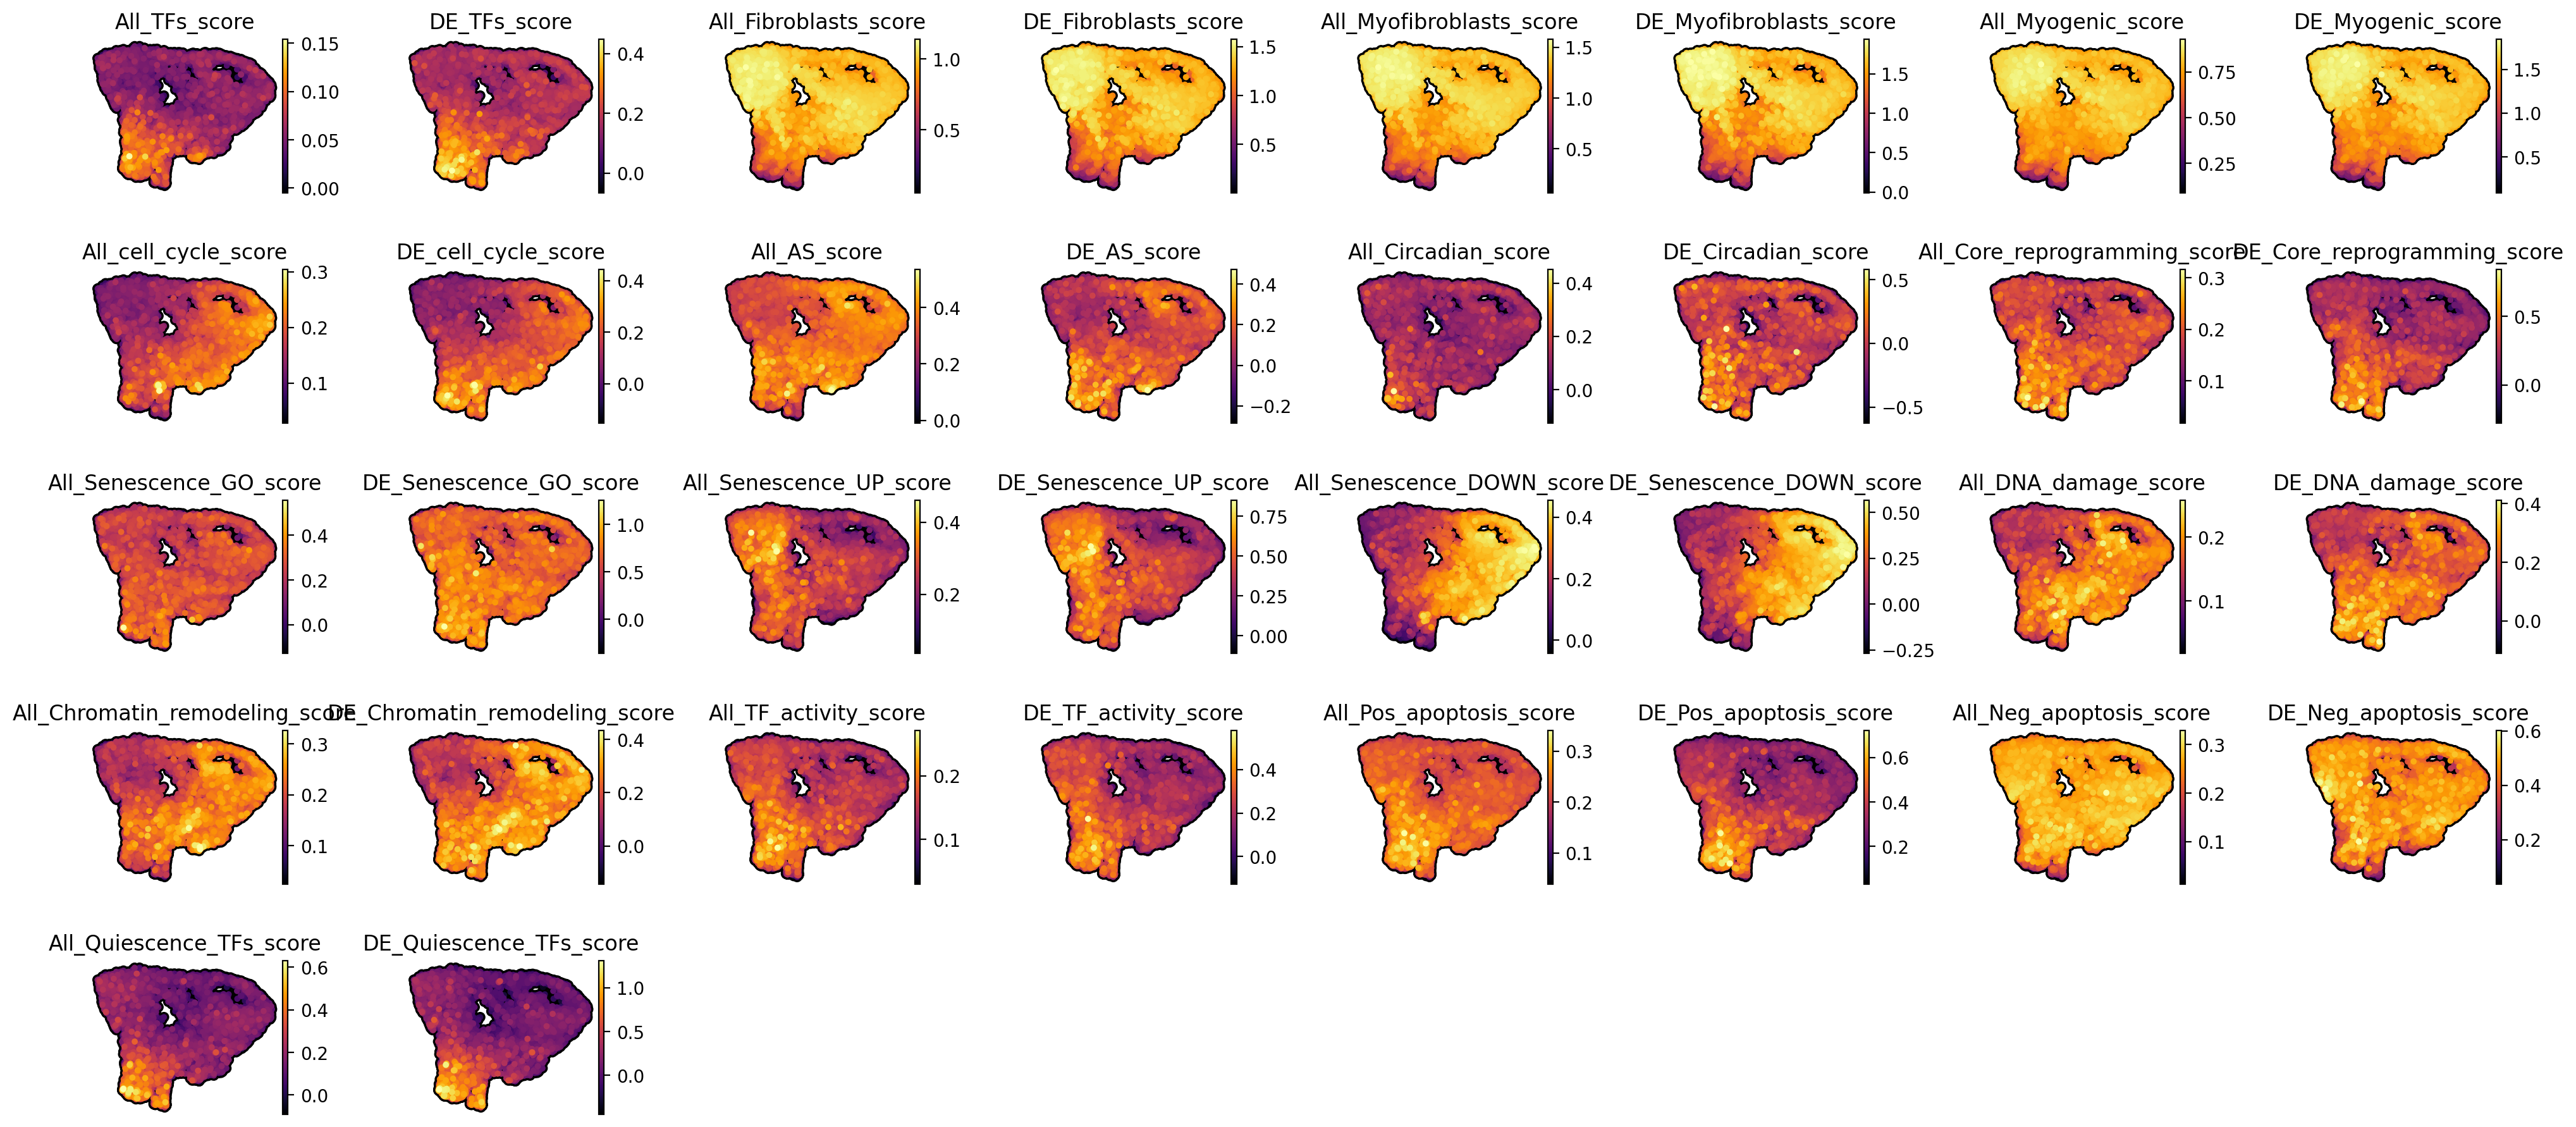

In [60]:
min_ctrl_size = 500

for geneset in cdf.columns:    
    
    all_score_name = f"All_{geneset}_score"
    de_score_name = f"DE_{geneset}_score"
    
    # Skip if scores already exist
    if all_score_name in adata.obs.columns and de_score_name in adata.obs.columns:
        print(f"Skipping {geneset}, scores already exist.")
        continue
        
    # get all genes belonging to geneset
    all_gene_list = cdf[geneset].unique()
    all_gene_list = [gene for gene in all_gene_list if gene in adata.var_names]
    
    # get DE geneset genes from adata
    sig_genes = sig_condition['names'].unique()
    de_gene_list = [gene for gene in sig_genes if gene in all_gene_list]
    
    # Set the ctrl_size to either 500 or the length of the gene list (whichever is larger)
    all_ctrl_size = max(min_ctrl_size, len(all_gene_list)) 
    de_ctrl_size = max(min_ctrl_size, len(de_gene_list))
    
    # Score ALL genes in geneset
    sc.tl.score_genes(
        adata,
        gene_list=all_gene_list,
        score_name=all_score_name,
        ctrl_size=all_ctrl_size,
        use_raw=False,
        layer='log_norm',
    )

    # Score just DE genes in geneset
    sc.tl.score_genes(
        adata,
        gene_list=de_gene_list,
        score_name=de_score_name,
        ctrl_size=de_ctrl_size,
        use_raw=False,
        layer='log_norm',
    )
    
print("Finished.")

# scores_to_plot = [col for col in adata.obs if col.startswith('DE')] + [col for col in adata.obs if col.startswith('All')]
scores_to_plot = [col for col in adata.obs if col.startswith(('DE', 'All'))]
print(len(scores_to_plot))

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2, 2

sc.pl.umap(
    adata,
    color=scores_to_plot,
    size=50,
    ncols=8,
    add_outline=True,
    outline_color=('k', 'k'),
    color_map='inferno',
    frameon=False,
    alpha=1,
    show=True,
    hspace=0.5,
    wspace=0.5,
)

In [62]:
tmp = round(len(scores_to_plot)/6)
tmp

6

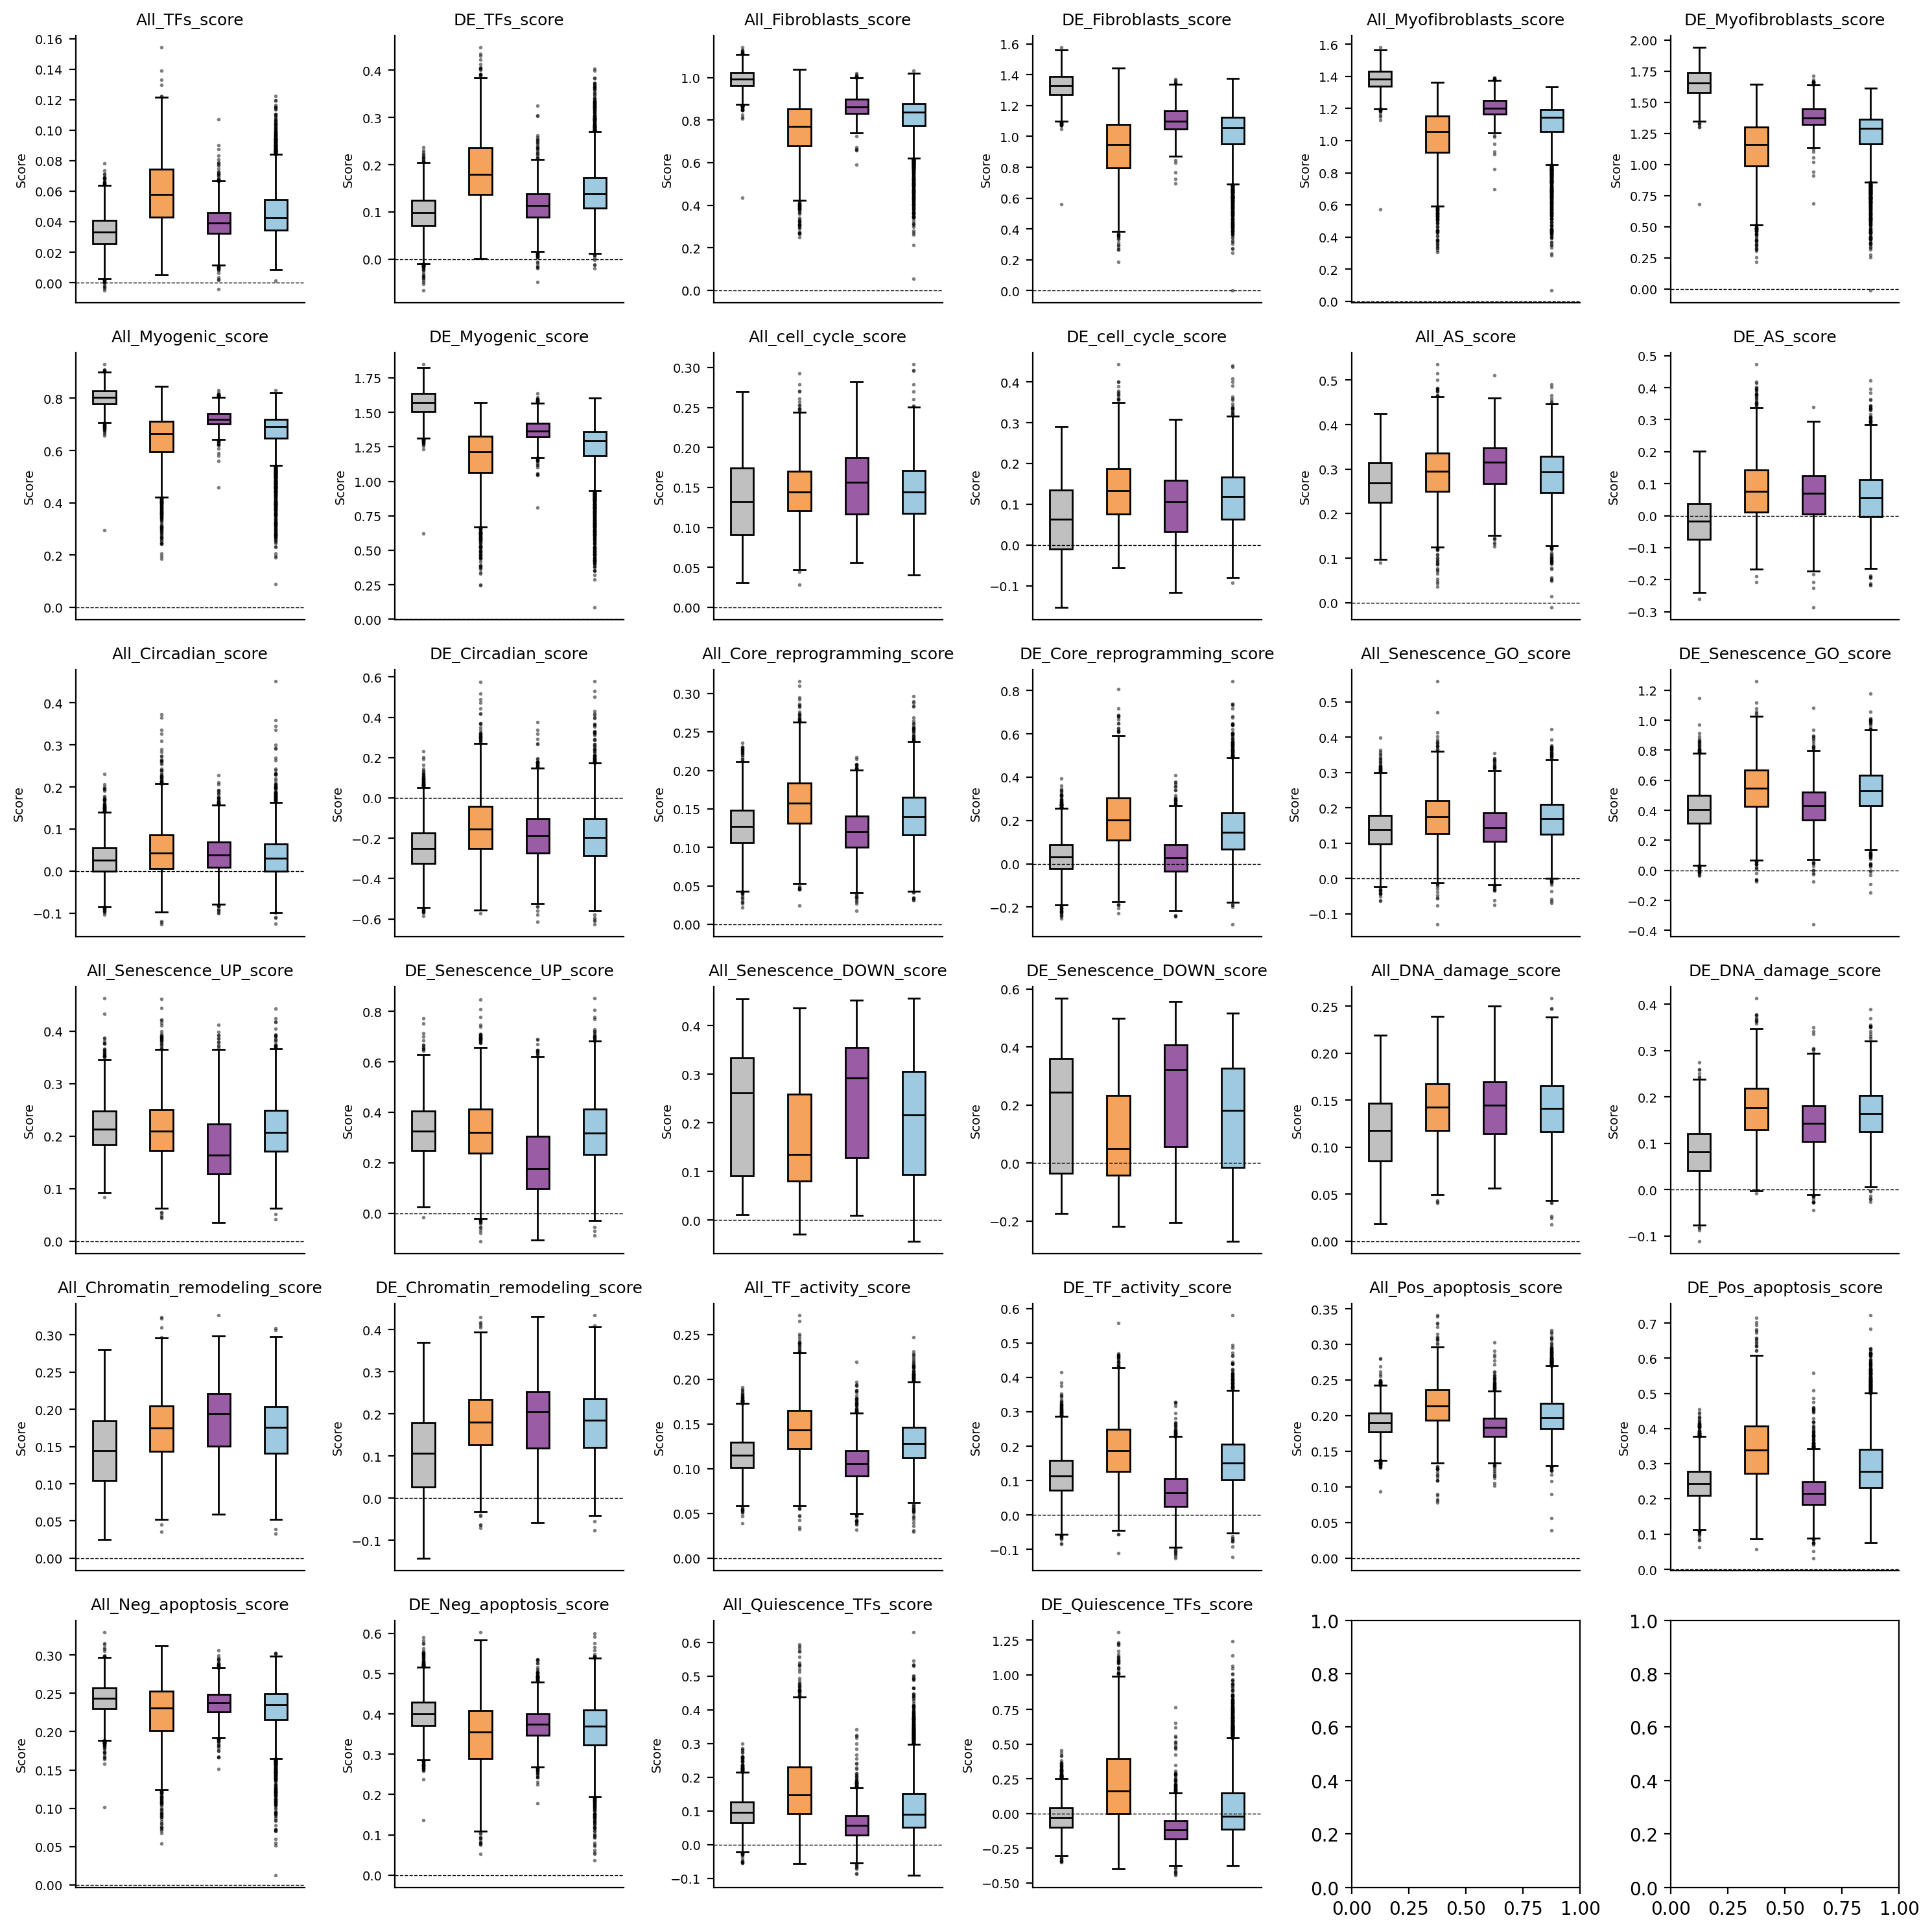

In [63]:
color_map = {
    "siPRRX1": "#9B5CA6",
    "siPRRX1/mmMYOD1": "#9ECAE1",
    "mmMYOD1": "#F5A35B",
    "Control": "silver"
}

ncols = 6
nrows = round(len(scores_to_plot)/ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15), dpi=200)
axes = axes.flatten()

for i, score in enumerate(scores_to_plot):
    ax = axes[i]
    
    title = score
    
    sns.boxplot(
        data=adata.obs,
        x='pooled_condition',
        y=score,
        width=0.4,
        linecolor='k',
        hue='pooled_condition',
        palette=color_map,
        legend=False,
        saturation=1,
        flierprops={'markersize': 1, 'alpha': 0.5},
        ax=ax,
        zorder=0,
    )
    
    ax.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=1)
    
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("")
    ax.set_xticks([])
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

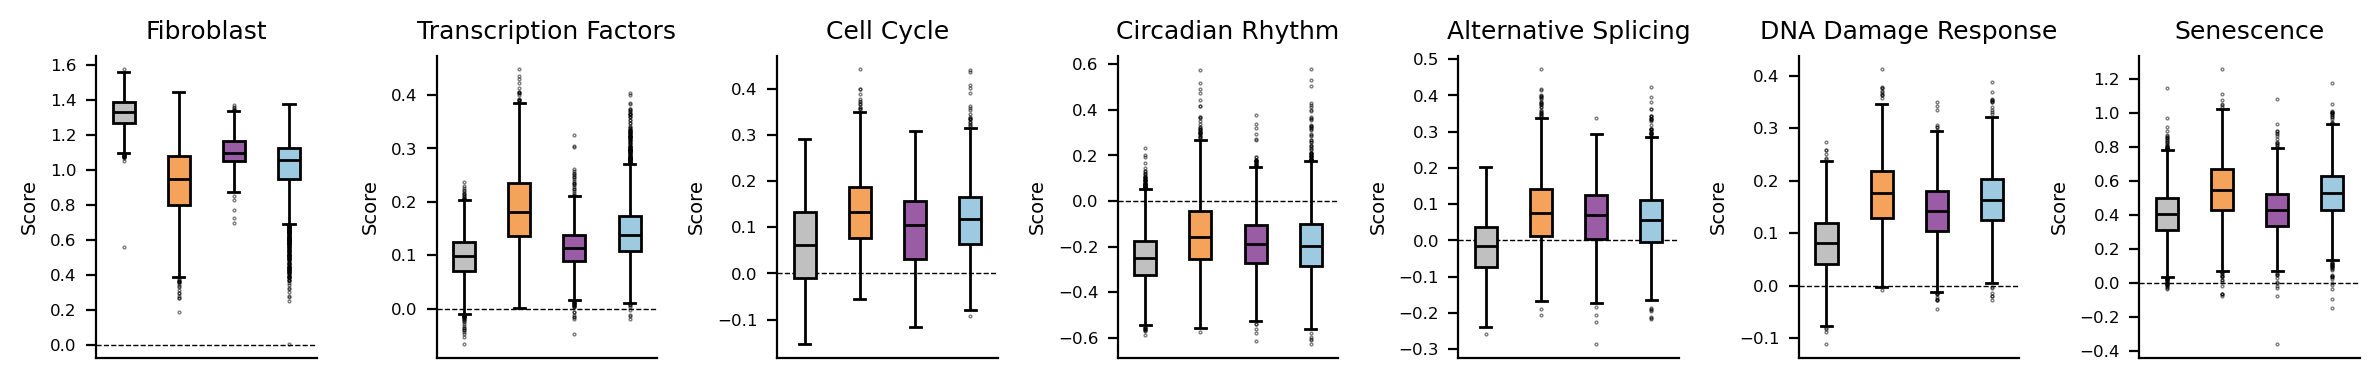

In [54]:
### Make panel of barplots for specific scores
title_map = {
    "AS": "Alternative Splicing",
    "TFs": "Transcription Factors",
    "TF_activity": "TF Activity", 
    "Fibroblasts": "Fibroblast",
    "Myofibroblasts": "Myofibroblast",
    "Myogenic": "Myogenic",
    "Core_reprogramming": "Core Reprogramming",
    "Circadian": "Circadian Rhythm",
    "cell_cycle": "Cell Cycle",
    "DNA_damage": "DNA Damage Response",
    "Senescence": "Senescence",
    "Pos_apoptosis": "Apoptosis",
}

scores_to_plot = [
    "DE_Fibroblasts_score",
    "DE_TFs_score",
    "DE_cell_cycle_score",
    "DE_Circadian_score",
    "DE_AS_score",
    "DE_DNA_damage_score",
    "DE_Senescence_GO_score",
]

fig, axes = plt.subplots(nrows=1, ncols=len(scores_to_plot), figsize=(12, 2), dpi=200)
axes = axes.flatten()

for i, score in enumerate(scores_to_plot):
    ax = axes[i]
    
    title = score # Default title if no specific mapping
    for k, v in title_map.items():
        if k in score:
            title = f"{v}"
    
    sns.boxplot(
        data=adata.obs,
        x='pooled_condition',
        y=score,
        width=0.4,
        linecolor='k',
        linewidth=1,
        hue='pooled_condition',
        palette=color_map,
        legend=False,
        saturation=1,
        flierprops={'markersize': 0.5, 'alpha': 0.5},
        ax=ax,
        zorder=1,
    )
    
    ax.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)
    
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("")
    ax.set_xticks([])
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(axis='y', labelsize=6)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()  

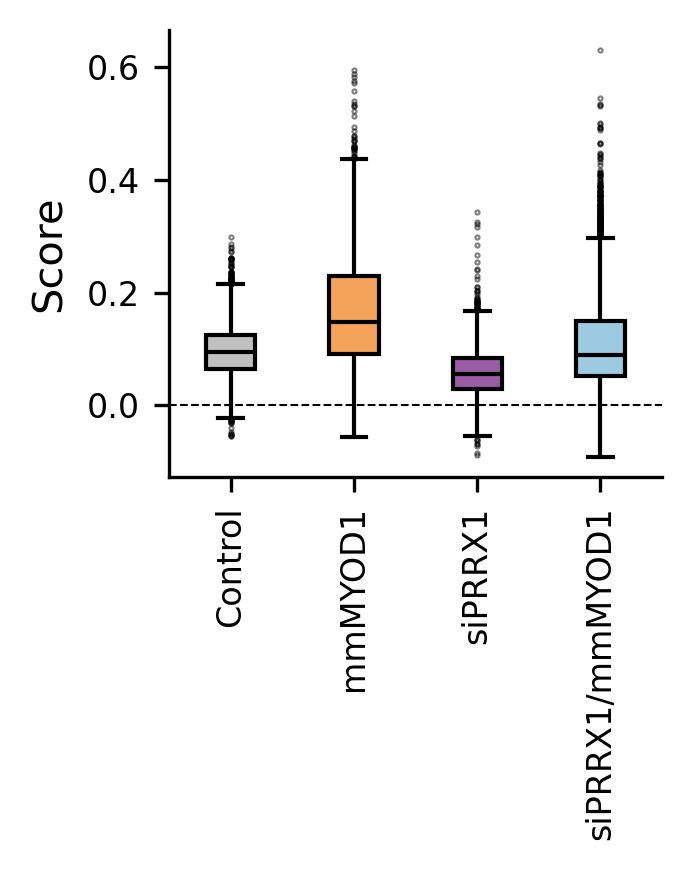

In [64]:
### Just 1 score
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.5, 3

sns.boxplot(
    data=adata.obs,
    x='pooled_condition',
    hue='pooled_condition',
    y='All_Quiescence_TFs_score',
    width=0.4,
    linecolor='k',
    linewidth=1,
    palette=color_map,
    legend=False,
    saturation=1,
    flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)

plt.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)

plt.ylabel('Score')
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.xlabel("")
sns.despine()

plt.tight_layout()
plt.show() 

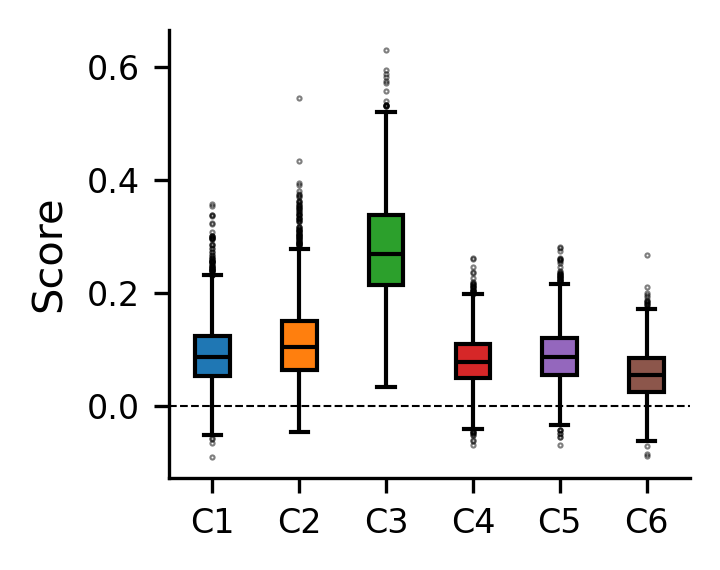

In [65]:
plt.rcParams['figure.figsize'] = 2.5, 2

sns.boxplot(
    data=adata.obs,
    x='cluster_str',
    hue='cluster_str',
    y='All_Quiescence_TFs_score',
    width=0.4,
    linecolor='k',
    linewidth=1,
    legend=False,
    saturation=1,
    flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)

plt.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)

plt.ylabel('Score')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel("")
sns.despine()

plt.tight_layout()
plt.show()